# Retriever Agent

### Imports

In [1]:
from src.graph.orchestrator_graph.retriever_agent.graphs import retriever_agent
from langchain_core.messages import HumanMessage
from src.graph.orchestrator_graph.preprocessing import prepare_orchestrator_input
from src.database.data_preprocessor import preprocess_user
from IPython.display import Image, display
from src.retrieval.retriever import retriever
from src.retrieval.reranker.reranker import reranker

/Users/rogier/dev/joho/advies_agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Static Retriever

In [2]:
docs = retriever.retrieve_company_docs("What coverage do i have for pregnancy?", "goudse_expat_pakket", 30)

In [29]:
# docs currently = [(Document, similarity_score), ...]

# 1. Extract Document objects
docs_only = [doc for doc, _ in docs]

# 2. Rerank
reranked_docs = reranker.rerank("What coverage do i have for pregnancy?", docs_only, 15)

# 3. Print results with scores
for i, doc in enumerate(reranked_docs, 1):
    score = doc.metadata.get("rerank_score", None)
    print(f"\nRank {i} | Rerank score: {score}")
    print(doc.page_content[:500])  # preview text


Rank 1 | Rerank score: 0.9701266884803772
## 3 What extra rights to reimbursement does the insured person have under the Optimal or Excellent cover?
### 3.3 Pregnancy and childbirth
#### 3.3.1 Birth

What will be reimbursed?
We reimburse all costs of delivery. For example, the costs for the use of a clinic or
hospital, the fee of the midwife or doctor and additional costs for mother and child.
We reimburse the stay in the hospital after the delivery for the mother and the child up
to 48 hours. We only reimburse longer stays if this is m

Rank 2 | Rerank score: 0.9152342677116394
## 2 Medical expenses
### 2.1 Coverage
#### Pregnancy and childbirth in case of a known pregnancy on the commencement date

The reimbursement for pregnancy and childbirth when the pregnancy is known on the commencement date. Under the Standard plan, this is Not covered. Under the Optimal plan, the max reimbursement is €2.500; starting the 10th month the regular coverage applies. Under the Excellent plan, the m

## Retriever Agent

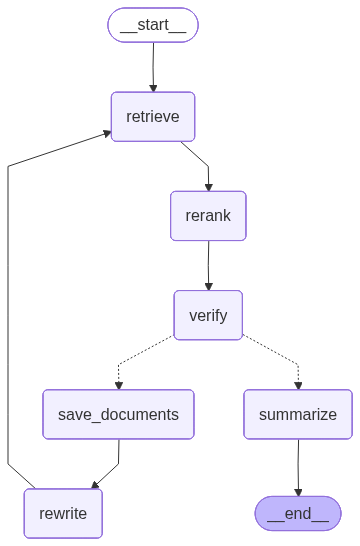

In [2]:
display(Image(retriever_agent.get_graph().draw_mermaid_png()))

In [7]:
result = retriever_agent.invoke({
    "messages": [HumanMessage(content="...")],
    "provider": "oom_wib",
    "query": "hoe zit het met wachtijden wat betreft zwangerschap en bevallingen?",
    "aspect": "zwangerschap",
    "product_description": "...",
    "retrieval_summary": {},
    "documents": [],
    "current_query": "",
    "evaluation_status": None,
    "retries": 0,
})

print(result["retrieval_summary"])

{'provider': 'oom_wib', 'aspect': 'zwangerschap', 'overall_summary': 'De documenten onderscheiden de dekkingsniveaus Regular, Comfort en DeLuxe voor (kosten rondom) zwangerschap en bevalling. Voor Comfort en DeLuxe geldt een wachttijd van 12 maanden vanaf ingangsdatum (of vanaf ingangsdatum van de hogere dekking bij upgrade) voordat zwangerschap/bevalling en kraamzorg worden vergoed. Voor zwangerschap/bevalling moet (in elk geval) uiterlijk 10 weken vóór de uitgerekende datum contact worden opgenomen met het OOM Assistance Centre om een geschikt ziekenhuis af te stemmen. In specifieke landen is voorafgaande toestemming (via OOM Assistance Centre) vereist; zonder toestemming volgt geen vergoeding (met uitzondering van acute zorg). Draagmoederschap is expliciet uitgesloten (ook bij onverwachte spoed). Een pasgeboren kind kan vanaf geboorte worden meeverzekerd zonder medische beoordeling als de geboorte binnen 1 maand wordt gemeld; dan zijn aangeboren aandoeningen ook gedekt. Aborting/zwa

In [4]:
result

{'messages': [HumanMessage(content='your query here', additional_kwargs={}, response_metadata={})],
 'provider': 'goudse_expat_pakket',
 'query': 'What coverage do i have for physiotherapy?',
 'aspect': 'physiotherapy coverage',
 'product_description': '...',
 'retrieval_summary': {'provider': 'goudse_expat_pakket',
  'aspect': 'physiotherapy coverage',
  'overall_summary': 'De documenten maken onderscheid tussen Standard, Optimal en Excellent. Er is een ‘coverage overview’ waarin het maximum aantal behandelingen staat; voor fysiotherapie (physiotherapy) en poliklinische revalidatie (outpatient rehabilitation) wordt expliciet verwezen naar dit maximum. Voor Optimal en Excellent worden ook voorwaarden en uitsluitingen genoemd (o.a. verwijzing door huisarts/specialist; uitsluitingen zoals manual therapy, met een nuance als de manual therapist ook fysiotherapeut is).',
  'coverage_level_findings': [{'coverage_level': 'Standard',
    'summary': 'Fysiotherapie (Physiotherapy) en manuele the

In [5]:
import os
print("LANGSMITH_TRACING:", os.environ.get("LANGSMITH_TRACING"))
print("LANGSMITH_API_KEY:", os.environ.get("LANGSMITH_API_KEY", "NOT SET")[:10] + "..." if os.environ.get("LANGSMITH_API_KEY") else "NOT SET")
print("LANGSMITH_PROJECT:", os.environ.get("LANGSMITH_PROJECT"))
print("LANGSMITH_ENDPOINT:", os.environ.get("LANGSMITH_ENDPOINT"))
print("---")
print("LANGCHAIN_TRACING_V2:", os.environ.get("LANGCHAIN_TRACING_V2"))
print("LANGCHAIN_API_KEY:", os.environ.get("LANGCHAIN_API_KEY", "NOT SET")[:10] + "..." if os.environ.get("LANGCHAIN_API_KEY") else "NOT SET")


LANGSMITH_TRACING: true
LANGSMITH_API_KEY: lsv2_pt_8b...
LANGSMITH_PROJECT: joho
LANGSMITH_ENDPOINT: https://api.smith.langchain.com
---
LANGCHAIN_TRACING_V2: None
LANGCHAIN_API_KEY: NOT SET
